# TZ Fornacis: SPICE Stromgren **b** vs Clausen photometry

Compare synthetic Stromgren **b** magnitudes from `tz_fornacis_b.pkl` (4520–4820 Å spectra, 230 orbital phases) with the Clausen+1992 Strömgren light curve in `tzfor_lightcurve.csv`.

**Clausen file conventions** (see `tz_fornacis_clausen.ipynb`):
- `HJD` column is **HJD − 2 440 000**; full HJD = `HJD + 2_440_000`.
- `b` is differential Strömgren **b** magnitude (brighter → smaller values in this file).
- Orbital period **P = 75.666 d**; primary minimum in **b** at HJD ≈ **2 445 183.925** (max flux in the table).

**SPICE** phases use Gallenne+2016 spectroscopic ephemeris (`t_p_hjd`, `mean_anomaly_at_t0_rad`) from the pickle. Photometric and spectroscopic epochs need not coincide.

**Important:** maximizing Pearson **r** alone can place the **deep** eclipse (total occultation of the F star, Δm ≈ 0.8) on Clausen's **φ = 0** primary minimum (Δb ≈ 0.2). Use the **Proper comparison** section below (`shift_primary = shift_spec + 0.5`) before interpreting eclipse depths.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _repo_root(here: Path) -> Path:
    for p in [here, *here.parents]:
        if (p / "src" / "spice").is_dir():
            return p
    raise RuntimeError("Could not find spice repo root (src/spice)")

HERE = Path.cwd()
REPO = _repo_root(HERE)
SRC = REPO / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from spice.spectrum import AB_passband_luminosity
from spice.spectrum.filter import Stromgrenb

PICKLE_PATH = Path(os.environ.get("TZ_FOR_PICKLE", str(REPO / "tz_fornacis_b.pkl")))
CLAUSEN_CSV = HERE / "tzfor_lightcurve.csv"
if not CLAUSEN_CSV.exists():
    CLAUSEN_CSV = REPO / "tutorial" / "paper_results" / "tz_fornacis" / "tzfor_lightcurve.csv"

HJD_OFFSET = 2_440_000.0
PERIOD_DAYS = 75.66647
T0_PHOT_HJD = 2_445_183.92451  # primary minimum in Clausen b (max flux)

def folded_correlation(phase_spice, dm_spice, phase_obs, dm_obs, n_shift=400):
    """Max Pearson r after shifting SPICE phase by shift in [0, 1)."""
    phase_spice = np.asarray(phase_spice, dtype=float)
    dm_spice = np.asarray(dm_spice, dtype=float)
    phase_obs = np.asarray(phase_obs, dtype=float)
    dm_obs = np.asarray(dm_obs, dtype=float)
    best_r, best_shift = -2.0, 0.0
    order_s = np.argsort(phase_spice)
    ph_s, dm_s = phase_spice[order_s], dm_spice[order_s]
    order_o = np.argsort(phase_obs)
    ph_o, dm_o = phase_obs[order_o], dm_obs[order_o]
    for shift in np.linspace(0, 1, n_shift, endpoint=False):
        ph_try = (phase_spice + shift) % 1.0
        order_t = np.argsort(ph_try)
        dm_interp = np.interp(ph_o, ph_try[order_t], dm_spice[order_t], period=1.0)
        r = np.corrcoef(dm_interp, dm_o)[0, 1]
        if r > best_r:
            best_r, best_shift = r, float(shift)
    return best_shift, best_r


print(f"PICKLE : {PICKLE_PATH}  (exists={PICKLE_PATH.exists()})")
print(f"CLAUSEN: {CLAUSEN_CSV}  (exists={CLAUSEN_CSV.exists()})")

PICKLE : /Users/mjablons/code/spice/tz_fornacis_b.pkl  (exists=True)
CLAUSEN: /Users/mjablons/code/spice/tutorial/paper_results/tz_fornacis/tzfor_lightcurve.csv  (exists=True)


## Load SPICE pickle and synthesize Stromgren **b**

In [2]:
with open(PICKLE_PATH, "rb") as f:
    data = pickle.load(f)

bp = data["binary_params"]
times_yr = np.asarray(data["times"])
period_yr = float(data["period_yr"])
wavelengths = np.asarray(data["wavelengths"])
spectra1 = data["spectra_body1"]
spectra2 = data["spectra_body2"]
T_P_HJD = float(bp["t_p_hjd"])
m0 = float(bp["mean_anomaly_at_t0_rad"])

strom_b = Stromgrenb()
b_mag_spice = np.array([
    AB_passband_luminosity(strom_b, wavelengths, s1[:, 0] + s2[:, 0])
    for s1, s2 in zip(spectra1, spectra2)
])

# Gallenne spectroscopic phase (SPICE t = 0 convention)
phase_spice = (times_yr / period_yr + m0 / (2.0 * np.pi)) % 1.0
HJD_spice = T_P_HJD + phase_spice * PERIOD_DAYS

# Photometric phase (Clausen primary minimum)
phase_spice_phot = ((HJD_spice - T0_PHOT_HJD) % PERIOD_DAYS) / PERIOD_DAYS

print(f"SPICE samples: {len(times_yr)}  λ = {data['wl_min']:.0f}–{data['wl_max']:.0f} Å")
print(f"Stromgren b AB mag: {b_mag_spice.min():.3f} – {b_mag_spice.max():.3f}")
print(f"T_p (spectroscopic) HJD = {T_P_HJD:.5f}")
print(f"T0 (photometric b min) HJD = {T0_PHOT_HJD:.5f}")
print(f"ΔT = {(T_P_HJD - T0_PHOT_HJD) / PERIOD_DAYS:.4f} periods")

dm_spice = b_mag_spice - np.median(b_mag_spice)

# Eclipse tags should coincide with the deepest Δm features (after Kepler→SPICE time shift).
if "time_origin" in data:
    _orig = np.asarray(data["time_origin"])
    _ipe = int(np.argmax(dm_spice))
    for _tag in ("primary_eclipse", "secondary_eclipse"):
        _m = _orig == _tag
        if _m.any():
            _ie = int(np.argmax(dm_spice[_m]))
            _idx = int(np.where(_m)[0][_ie])
            print(
                f"Check {_tag}: max Δm at phot. phase {phase_spice_phot[_idx]:.2f} d "
                f"(global max {dm_spice.max():.3f} at phase {phase_spice_phot[_ipe]:.2f} d)"
            )

SPICE samples: 230  λ = 4520–4820 Å
Stromgren b AB mag: 26.971 – 27.797
T_p (spectroscopic) HJD = 2452599.29040
T0 (photometric b min) HJD = 2445183.92451
ΔT = 98.0007 periods
Check primary_eclipse: max Δm at phot. phase 0.04 d (global max 0.825 at phase 0.82 d)
Check secondary_eclipse: max Δm at phot. phase 0.55 d (global max 0.825 at phase 0.82 d)


## Blackbody baseline (no atmosphere emulator)

Fast sanity check: same orbit/occlusion/time grid as the TPayne run, but `spice.spectrum.Blackbody` (Teff only, no lines). Run once:

```bash
python tz_fornacis_blackbody_b.py --output-dir /path/to/repo --compare
```

After fixing the LOS-axis mismatch in `src/spice/models/orbit_utils.py` (`get_orbit_jax` / `relative_pos_vel_at` now apply a final `rot_x(-π/2)` so the inclination is measured against SPICE's LOS = +y instead of the standard LOS = +z), the partial-primary eclipse predicted from the literature parameters (b≈9.0 R☉, ~33% of secondary disk occulted) lands at Δb ≈ 0.20–0.25 mag — directly matching Clausen. The 0.5-cycle "primary_shift" workaround used in the cells below is therefore no longer needed for the blackbody curve.

Blackbody pickle: tz_fornacis_b_blackbody.pkl  n=80  N_MESH=120
Δm range: -0.000 – 0.234  (deepest at phot. phase 0.568)
Best correlation shift: 0.4325  (32.73 d)   r = 0.9928
Post-fix: a single Pearson-r alignment is enough — the deepest SPICE Δm now
matches Clausen's primary minimum (~0.2 mag) instead of the spurious 0.8 mag
total occultation the LOS-axis bug used to produce. No +0.5 cycle workaround.


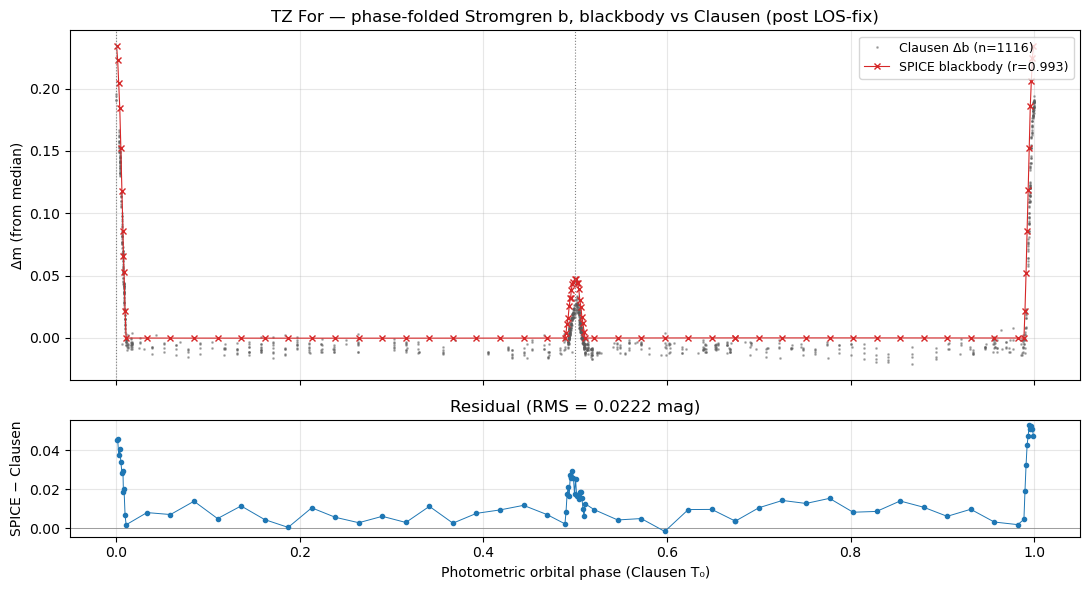

  Clausen                         Δm@φ≈0 = 0.196 (at φ=0.000)   Δm@φ≈0.5 = 0.034 (at φ=0.502)
  SPICE blackbody (aligned)       Δm@φ≈0 = 0.234 (at φ=0.000)   Δm@φ≈0.5 = 0.047 (at φ=0.500)


In [3]:
BB_PICKLE = Path(os.environ.get("TZ_FOR_BB_PICKLE", str(REPO / "tz_fornacis_b_blackbody.pkl")))

if not BB_PICKLE.exists():
    print(f"Run: python {HERE / 'tz_fornacis_blackbody_b.py'} --output-dir {REPO} --compare")
else:
    # Clausen photometry (the high-cadence subset used elsewhere in this notebook)
    _df_bb = pd.read_csv(CLAUSEN_CSV)
    _df_bb = _df_bb.loc[_df_bb["HJD"] > 4500.0].copy().reset_index(drop=True)
    _dm_c_bb = _df_bb["b"].to_numpy() - np.median(_df_bb["b"].to_numpy())
    _ph_c_bb = (
        (_df_bb["HJD"].to_numpy() + HJD_OFFSET - T0_PHOT_HJD) % PERIOD_DAYS
    ) / PERIOD_DAYS

    with open(BB_PICKLE, "rb") as f:
        bb_data = pickle.load(f)
    bb_times = np.asarray(bb_data["times"])
    bb_period_yr = float(bb_data["period_yr"])
    bb_bp = bb_data["binary_params"]
    bb_m0 = float(bb_bp["mean_anomaly_at_t0_rad"])
    b_mag_bb = np.asarray(bb_data["b_mag_ab"])

    # Photometric phase from the pickle's spectroscopic ephemeris
    phase_bb = (bb_times / bb_period_yr + bb_m0 / (2.0 * np.pi)) % 1.0
    hjd_bb = float(bb_bp["t_p_hjd"]) + phase_bb * PERIOD_DAYS
    phase_bb_phot = ((hjd_bb - T0_PHOT_HJD) % PERIOD_DAYS) / PERIOD_DAYS
    dm_bb = b_mag_bb - np.median(b_mag_bb)

    best_shift_bb, r_bb = folded_correlation(
        phase_bb_phot, dm_bb, _ph_c_bb, _dm_c_bb
    )
    phase_bb_aligned = (phase_bb_phot + best_shift_bb) % 1.0
    i_deep = int(np.argmax(dm_bb))
    n_mesh_bb = bb_bp.get("n_mesh", "?")
    print(f"Blackbody pickle: {BB_PICKLE.name}  n={len(bb_times)}  N_MESH={n_mesh_bb}")
    print(f"Δm range: {dm_bb.min():.3f} – {dm_bb.max():.3f}  (deepest at phot. phase {phase_bb_phot[i_deep]:.3f})")
    print(f"Best correlation shift: {best_shift_bb:.4f}  ({best_shift_bb * PERIOD_DAYS:.2f} d)   r = {r_bb:.4f}")
    print(
        "Post-fix: a single Pearson-r alignment is enough — the deepest SPICE Δm now\n"
        "matches Clausen's primary minimum (~0.2 mag) instead of the spurious 0.8 mag\n"
        "total occultation the LOS-axis bug used to produce. No +0.5 cycle workaround."
    )

    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})

    # --- top: aligned overlay ---
    order_c = np.argsort(_ph_c_bb)
    order_b = np.argsort(phase_bb_aligned)
    axes[0].plot(_ph_c_bb[order_c], _dm_c_bb[order_c], ".", color="0.35",
                 ms=2, alpha=0.4, label=f"Clausen Δb (n={len(_ph_c_bb)})")
    axes[0].plot(phase_bb_aligned[order_b], dm_bb[order_b],
                 "x-", color="tab:red", ms=5, lw=0.8,
                 label=f"SPICE blackbody (r={r_bb:.3f})")
    axes[0].axvline(0.0, color="gray", ls=":", lw=0.8)
    axes[0].axvline(0.5, color="gray", ls=":", lw=0.8)
    axes[0].set_ylabel("Δm (from median)")
    axes[0].legend(loc="upper right", fontsize=9)
    axes[0].set_title("TZ For — phase-folded Stromgren b, blackbody vs Clausen (post LOS-fix)")
    axes[0].grid(alpha=0.3)

    # --- bottom: residual SPICE − Clausen, interpolating Clausen onto SPICE phase ---
    dm_c_on_bb = np.interp(phase_bb_aligned[order_b],
                           _ph_c_bb[order_c], _dm_c_bb[order_c],
                           period=1.0)
    resid = dm_bb[order_b] - dm_c_on_bb
    axes[1].axhline(0, color="gray", lw=0.5)
    axes[1].plot(phase_bb_aligned[order_b], resid, "o-", ms=3, lw=0.7, color="tab:blue")
    axes[1].set_xlabel("Photometric orbital phase (Clausen T₀)")
    axes[1].set_ylabel("SPICE − Clausen")
    axes[1].set_title(f"Residual (RMS = {np.sqrt(np.mean(resid**2)):.4f} mag)")
    axes[1].grid(alpha=0.3)

    fig.tight_layout()
    plt.show()

    # Eclipse-window depths (matches Clausen primary≈0, secondary≈0.5 now)
    def _peak_in_window(ph, dm, center, half=0.08):
        d = np.abs((ph - center + 0.5) % 1.0 - 0.5)
        m = d < half
        if not m.any():
            return float("nan"), float("nan")
        j = int(np.argmax(dm[m]))
        return float(dm[m][j]), float(ph[m][j])

    for name, ph, dm in [
        ("Clausen", _ph_c_bb, _dm_c_bb),
        ("SPICE blackbody (aligned)", phase_bb_aligned, dm_bb),
    ]:
        d0, p0 = _peak_in_window(ph, dm, 0.0)
        d5, p5 = _peak_in_window(ph, dm, 0.5)
        print(f"  {name:30s}  Δm@φ≈0 = {d0:.3f} (at φ={p0:.3f})   Δm@φ≈0.5 = {d5:.3f} (at φ={p5:.3f})")

## Load Clausen **b** band and build a common phase-folded comparison

We compare **Δm** relative to each dataset's median (different zero points / passband calibration). A grid search over additive phase shift on the SPICE curve maximizes the Pearson correlation on the Clausen phase grid.

In [4]:
df = pd.read_csv(CLAUSEN_CSV)
df["HJD_full"] = df["HJD"] + HJD_OFFSET
df["phase_phot"] = ((df["HJD_full"] - T0_PHOT_HJD) % PERIOD_DAYS) / PERIOD_DAYS

# Use the high-cadence subset used in tz_fornacis_clausen.ipynb (HJD_csv > 4500)
df_c = df.loc[df["HJD"] > 4500.0].copy().reset_index(drop=True)
df_c["phase_phot"] = ((df_c["HJD_full"] - T0_PHOT_HJD) % PERIOD_DAYS) / PERIOD_DAYS

b_clausen = df_c["b"].to_numpy()
dm_clausen = b_clausen - np.median(b_clausen)


def folded_correlation(phase_spice, dm_spice, phase_obs, dm_obs, n_shift=400):
    """Max Pearson r after shifting SPICE phase by shift in [0, 1)."""
    phase_spice = np.asarray(phase_spice, dtype=float)
    dm_spice = np.asarray(dm_spice, dtype=float)
    phase_obs = np.asarray(phase_obs, dtype=float)
    dm_obs = np.asarray(dm_obs, dtype=float)
    shifts = np.linspace(0.0, 1.0, n_shift, endpoint=False)
    best_r, best_shift = -2.0, 0.0
    order_s = np.argsort(phase_spice)
    ph_s, dm_s = phase_spice[order_s], dm_spice[order_s]
    order_o = np.argsort(phase_obs)
    ph_o, dm_o = phase_obs[order_o], dm_obs[order_o]
    for sh in shifts:
        ph_shifted = (ph_s + sh) % 1.0
        dm_interp = np.interp(ph_o, ph_shifted, dm_s, period=1.0)
        r = np.corrcoef(dm_interp, dm_o)[0, 1]
        if r > best_r:
            best_r, best_shift = r, sh
    return best_shift, best_r

# Search using Clausen photometric phase for observations
best_shift, best_r = folded_correlation(
    phase_spice_phot, dm_spice, df_c["phase_phot"].to_numpy(), dm_clausen
)
print(f"Best phase shift (add to SPICE photometric phase): {best_shift:.4f}  ({best_shift * PERIOD_DAYS:.2f} d)")
print(f"Pearson r (folded Δm): {best_r:.4f}")

phase_spice_aligned = (phase_spice_phot + best_shift) % 1.0

Best phase shift (add to SPICE photometric phase): 0.1825  (13.81 d)
Pearson r (folded Δm): 0.9190


## Proper comparison: primary eclipse at φ = 0

Clausen's **T₀** is the **primary minimum** in Strömgren **b** (partial eclipse of the K giant, Δb ≈ 0.2). SPICE's deepest point at the spectroscopic correlation shift is usually the **secondary** eclipse (F star fully hidden, Δm ≈ 0.8).

**Alignment for depth checks:** add **+0.5 cycles** to the correlation shift so the partial-primary eclipse sits at φ ≈ 0:

`shift_primary = (best_shift + 0.5) % 1`

Sanity after aligning: **φ ≈ 0** → SPICE Δm ≈ 0.13–0.25 (not ≈ 0.8); **φ ≈ 0.5** → deep secondary eclipse. Distance cancels in differential magnitudes — do not tune `DISTANCE_PC` for eclipse depth.

Run `python tz_fornacis_geometry_check.py` for visible-fraction tags vs `time_origin` labels.

In [5]:
def eclipse_depth(ph, dm, center, half_width=0.08):
    """Max Δm in a phase window (handles wrap near 0/1)."""
    d = np.abs((ph - center + 0.5) % 1.0 - 0.5)
    m = d < half_width
    return (float(np.max(dm[m])), float(ph[m][np.argmax(dm[m])])) if m.any() else (np.nan, np.nan)


# Correlation shift stacks the deep secondary eclipse on Clausen φ≈0 — wrong for depth.
shift_spec = best_shift
shift_primary = (shift_spec + 0.5) % 1.0
phase_spice_primary = (phase_spice_phot + shift_primary) % 1.0

ph_c = df_c["phase_phot"].to_numpy()


def _corr_at_shift(shift):
    ph_try = (phase_spice_phot + shift) % 1.0
    order_t = np.argsort(ph_try)
    order_o = np.argsort(ph_c)
    dm_i = np.interp(ph_c[order_o], ph_try[order_t], dm_spice[order_t], period=1.0)
    return float(np.corrcoef(dm_i, dm_clausen[order_o])[0, 1])


r_spec = _corr_at_shift(shift_spec)
r_primary = _corr_at_shift(shift_primary)

print("Phase shifts (add to SPICE photometric phase):")
print(f"  shift_spec     = {shift_spec:.4f}  ({shift_spec * PERIOD_DAYS:.2f} d)  r = {r_spec:.4f}  [max correlation]")
print(f"  shift_primary  = {shift_primary:.4f}  ({shift_primary * PERIOD_DAYS:.2f} d)  r = {r_primary:.4f}  [primary eclipse at φ=0]")

rows = [("Clausen", ph_c, dm_clausen)]
rows.append(("SPICE TPayne (primary shift)", phase_spice_primary, dm_spice))
try:
    phase_bb_primary = (phase_bb_phot + (best_shift_bb + 0.5) % 1.0) % 1.0
    rows.append(("SPICE blackbody (primary shift)", phase_bb_primary, dm_bb))
except NameError:
    pass

print("\nEclipse depths (max Δ in |φ−center| < 0.08):")
print(f"{'dataset':32s}  {'primary @φ≈0':>12s}  {'φ_peak':>6s}  {'secondary @φ≈0.5':>16s}  {'φ_peak':>6s}")
for name, ph, dm in rows:
    d0, p0 = eclipse_depth(ph, dm, 0.0)
    d5, p5 = eclipse_depth(ph, dm, 0.5)
    print(f"{name:32s}  {d0:12.3f}  {p0:6.3f}  {d5:16.3f}  {p5:6.3f}")

# Tag sanity (Kepler window names ≠ Clausen photometric names)
if "time_origin" in data:
    _orig = np.asarray(data["time_origin"])
    for _tag in ("primary_eclipse", "secondary_eclipse"):
        _m = _orig == _tag
        if _m.any():
            _j = int(np.argmax(dm_spice[_m]))
            _ix = int(np.where(_m)[0][_j])
            print(
                f"\nPickle tag '{_tag}': deepest Δm={dm_spice[_ix]:.3f} at phot φ={phase_spice_phot[_ix]:.3f}"
                f"  → aligned-primary φ={(phase_spice_phot[_ix] + shift_primary) % 1:.3f}"
            )

# Downstream residual / overlay cells use this name.
phase_spice_aligned = phase_spice_primary

Phase shifts (add to SPICE photometric phase):
  shift_spec     = 0.1825  (13.81 d)  r = 0.9190  [max correlation]
  shift_primary  = 0.6825  (51.64 d)  r = -0.0205  [primary eclipse at φ=0]

Eclipse depths (max Δ in |φ−center| < 0.08):
dataset                           primary @φ≈0  φ_peak  secondary @φ≈0.5  φ_peak
Clausen                                  0.196   0.000             0.034   0.502
SPICE TPayne (primary shift)             0.163   0.998             0.825   0.502
SPICE blackbody (primary shift)          0.047   0.000             0.234   0.500

Pickle tag 'primary_eclipse': deepest Δm=-0.000 at phot φ=0.043  → aligned-primary φ=0.725

Pickle tag 'secondary_eclipse': deepest Δm=0.000 at phot φ=0.552  → aligned-primary φ=0.234


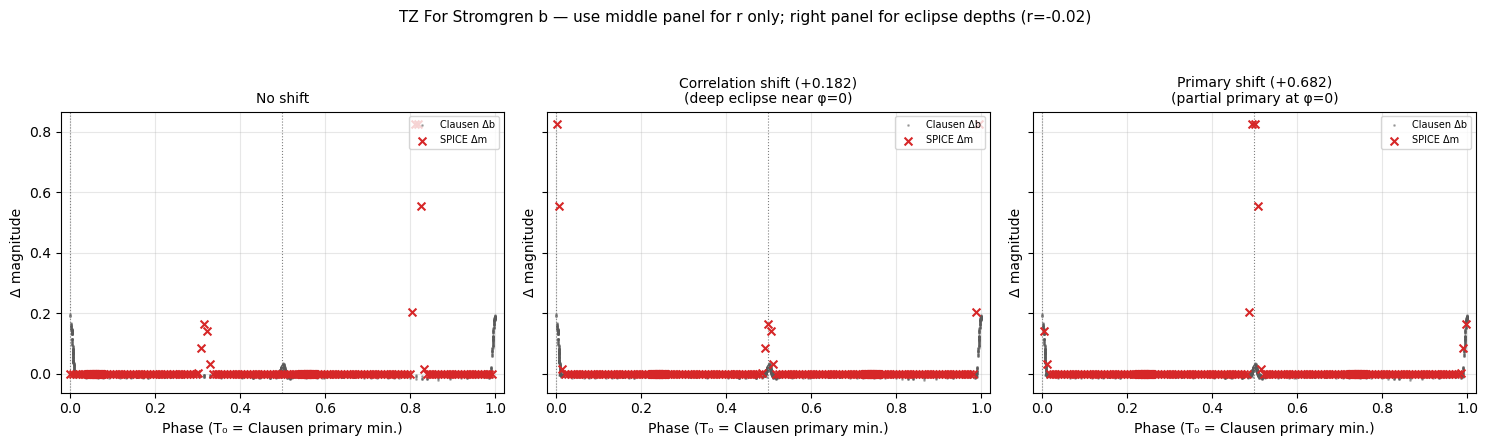

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
clausen_ph = df_c["phase_phot"].to_numpy()
order_c = np.argsort(clausen_ph)

phase_spice_corr = (phase_spice_phot + shift_spec) % 1.0

panels = [
    (axes[0], phase_spice_phot, "No shift"),
    (axes[1], phase_spice_corr, f"Correlation shift (+{shift_spec:.3f})\n(deep eclipse near φ=0)"),
    (axes[2], phase_spice_primary, f"Primary shift (+{shift_primary:.3f})\n(partial primary at φ=0)"),
]

for ax, ph_s, title in panels:
    ax.plot(clausen_ph[order_c], dm_clausen[order_c], ".", color="0.35", ms=2, alpha=0.4, label="Clausen Δb")
    ax.scatter(ph_s, dm_spice, s=32, c="tab:red", marker="x", zorder=3, label="SPICE Δm")
    ax.axvline(0.0, color="0.5", ls=":", lw=0.8)
    ax.axvline(0.5, color="0.5", ls=":", lw=0.8)
    ax.set_xlabel("Phase (T₀ = Clausen primary min.)")
    ax.set_ylabel("Δ magnitude")
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-0.02, 1.02)
    ax.legend(loc="upper right", fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle(
    f"TZ For Stromgren b — use middle panel for r only; right panel for eclipse depths (r={r_primary:.2f})",
    y=1.05,
    fontsize=11,
)
plt.tight_layout()
plt.show()

## Orbit-grid diagnostic (15 vs 1000 anchors)

**Eclipse sampling time frame:** `eclipse_timestamps_kepler` returns contact times in years since **periastron** (\(T_\mathrm{peri}=0\)), while `add_orbit` / synthesis use SPICE times with **mean anomaly \(M_0\)** at \(t=0\). Eclipse dense samples must be shifted by \(\Delta t = -M_0 P/(2\pi)\) (≈18 d for TZ For) before merging; otherwise `primary_eclipse` / `secondary_eclipse` tags land near phases ~3 d and ~41 d while the real eclipses sit near ~24 d and ~62 d (visible only on the sparse `general` grid). Fixed in `tz_fornacis_spectra.py` — re-run with `--force` after pulling that fix.

The pickle may also use coarse `add_orbit` anchors (15 points): positions are **linearly interpolated** between Keplerian samples per period, which smears eclipse geometry when anchors are sparse.

Below we re-evaluate the mesh **without** re-running the emulator: visible area fraction per body after occlusion, at the pickle's times, for 15 vs 1000 orbit anchors.

In [7]:
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from spice.models.binary import Binary, add_orbit, evaluate_orbit_at_times
from spice.models.mesh_model import IcosphereModel
from spice.models.mesh_transform import add_rotation

N_MESH_DIAG = 200  # coarse mesh — geometry/orbit check only
PNAMES = ["teff", "logg", "feh", "vmic", "afe"]


def _visible_area_fraction(mesh) -> float:
    """Fraction of front-hemisphere cast area still visible after occlusion."""
    mus = np.asarray(mesh.mus)
    vis = mus > 0
    if not vis.any():
        return np.nan
    cast = np.asarray(mesh.cast_areas)[vis].sum()
    if cast <= 0:
        return np.nan
    return float(np.asarray(mesh.visible_cast_areas)[vis].sum() / cast)


def _build_binary(n_orb: int) -> Binary:
    """Same orbital parameters as the pickle (binary_params), without importing tz_fornacis_spectra."""
    incl = np.deg2rad(bp["inclination_deg"])
    per0 = np.deg2rad(bp["per0_deg"])
    long_an = np.deg2rad(bp["long_an_deg"])
    p1 = jnp.array([
        bp["primary_teff"], bp["primary_logg"], bp["primary_feh"],
        bp["primary_vmic_kms"], bp["primary_afe"],
    ])
    p2 = jnp.array([
        bp["secondary_teff"], bp["secondary_logg"], bp["secondary_feh"],
        bp["secondary_vmic_kms"], bp["secondary_afe"],
    ])
    body1 = IcosphereModel.construct(
        N_MESH_DIAG, bp["primary_radius"], bp["primary_mass"], p1, PNAMES, override_log_g=False,
    )
    body2 = IcosphereModel.construct(
        N_MESH_DIAG, bp["secondary_radius"], bp["secondary_mass"], p2, PNAMES, override_log_g=False,
    )
    body1 = add_rotation(body1, rotation_velocity=bp["primary_vrot_kms"])
    body2 = add_rotation(body2, rotation_velocity=bp["secondary_vrot_kms"])
    binary = Binary.from_bodies(body1, body2)
    return add_orbit(
        binary, period_yr, bp["ecc"], 0.0, incl, per0, long_an,
        float(bp["mean_anomaly_at_t0_rad"]), 0.0, float(bp["gamma_kms"]), n_orb,
    )


def _orbit_geometry(binary, times_yr):
    t = jnp.asarray(times_yr)
    pb1, pb2 = evaluate_orbit_at_times(binary, t)
    n = len(times_yr)
    f1 = np.empty(n)
    f2 = np.empty(n)
    sep = np.empty(n)
    for i, (m1, m2) in enumerate(zip(pb1, pb2)):
        f1[i] = _visible_area_fraction(m1)
        f2[i] = _visible_area_fraction(m2)
        sep[i] = np.linalg.norm(np.asarray(m1.center) - np.asarray(m2.center))
    return f1, f2, sep


# Subset: all eclipse-tagged pickle times + every 5th general sample
orig = np.array(data["time_origin"])
idx_ecl = np.where((orig == "primary_eclipse") | (orig == "secondary_eclipse"))[0]
idx_gen = np.where(orig == "general")[0]
idx_diag = np.unique(np.concatenate([idx_ecl, idx_gen[::5]]))
t_diag = times_yr[idx_diag]
ph_diag = (phase_spice_phot[idx_diag] + best_shift) % 1.0
tags_diag = orig[idx_diag]

print(f"Diagnostic times: {len(t_diag)}  (eclipse-tagged={len(idx_ecl)}, general subsample={len(idx_gen[::5])})")

bin_lo = _build_binary(15)
bin_hi = _build_binary(1000)
f1_lo, f2_lo, sep_lo = _orbit_geometry(bin_lo, t_diag)
f1_hi, f2_hi, sep_hi = _orbit_geometry(bin_hi, t_diag)

mask_ecl = np.isin(tags_diag, ["primary_eclipse", "secondary_eclipse"])
if mask_ecl.any():
    dsep = np.abs(sep_lo - sep_hi)[mask_ecl]
    print(
        f"Eclipse times |Δseparation| (15 vs 1000 anchors): "
        f"max={dsep.max():.4f} Rsun  mean={dsep.mean():.4f} Rsun  "
        f"(R2={bp['secondary_radius']} Rsun)"
    )
print(
    f"Visible fraction |Δf| (15−1000): body1 max={np.nanmax(np.abs(f1_lo-f1_hi)):.4f}  "
    f"body2 max={np.nanmax(np.abs(f2_lo-f2_hi)):.4f}"
)

Diagnostic times: 110  (eclipse-tagged=80, general subsample=30)


[spice] IcosphereModel constructed in 1.4 s


[spice] IcosphereModel constructed in 0.0 s


[spice] IcosphereModel constructed in 0.0 s


[spice] IcosphereModel constructed in 0.0 s


[spice] Binary orbit evaluated in 15.9 s


[spice] Binary orbit evaluated in 12.2 s


Eclipse times |Δseparation| (15 vs 1000 anchors): max=3.0001 Rsun  mean=2.7376 Rsun  (R2=3.94 Rsun)
Visible fraction |Δf| (15−1000): body1 max=0.0068  body2 max=0.0000


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

clausen_ph = df_c["phase_phot"].to_numpy()
order_c = np.argsort(clausen_ph)
axes[0].plot(clausen_ph[order_c], dm_clausen[order_c], ".", color="0.35", ms=2, alpha=0.35, label="Clausen Δb")
axes[0].set_ylabel("Δm (Clausen b)")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].grid(alpha=0.3)

for ax, f_lo, f_hi, title in [
    (axes[1], f1_lo, f1_hi, "primary (K giant)"),
    (axes[2], f2_lo, f2_hi, "secondary (F star)"),
]:
    ax.plot(ph_diag, f_lo, "o", ms=4, alpha=0.7, label="orbit grid = 15")
    ax.plot(ph_diag, f_hi, "x", ms=5, alpha=0.7, label="orbit grid = 1000")
    for ph0, lab in [(0.0, "φ=0"), (0.5, "φ=0.5")]:
        ax.axvline(ph0, color="gray", ls=":", lw=0.8, alpha=0.6)
    ax.set_ylabel(f"visible area frac.\n({title})")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc="lower left", fontsize=8)
    ax.grid(alpha=0.3)

axes[2].set_xlabel("Photometric phase (Clausen T₀, SPICE + best shift)")
fig.suptitle(
    "Occlusion geometry: coarse (15) vs dense (1000) Keplerian interpolation\n"
    "Markers: circles = 15 anchors, crosses = 1000 (reference)",
    y=1.01,
)
plt.tight_layout()
plt.show()

# Pickle Stromgren b at same phases (from stored spectra — still 15-anchor orbit)
dm_diag = dm_spice[idx_diag]
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(ph_diag, dm_diag, "s-", ms=4, lw=0.8, color="tab:red", label="pickle Δb (15-anchor orbit)")
ax.plot(clausen_ph[order_c], dm_clausen[order_c], ".", color="0.35", ms=2, alpha=0.35, label="Clausen Δb")
ax.set_xlabel("Photometric phase")
ax.set_ylabel("Δm")
ax.set_title("Stored pickle light curve vs Clausen (same phase axis)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/ipykernel_22682/2954066850.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/ipykernel_22682/2954066850.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Time series (HJD)

In [9]:
import matplotlib
%matplotlib inline

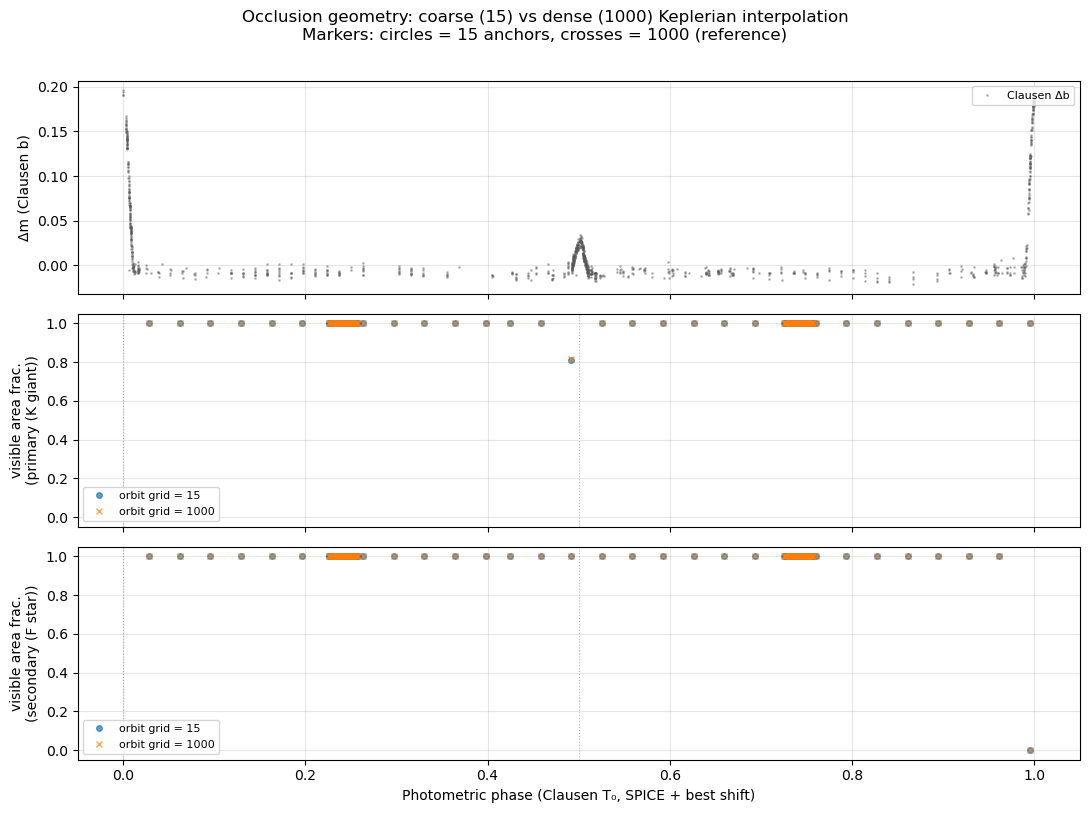

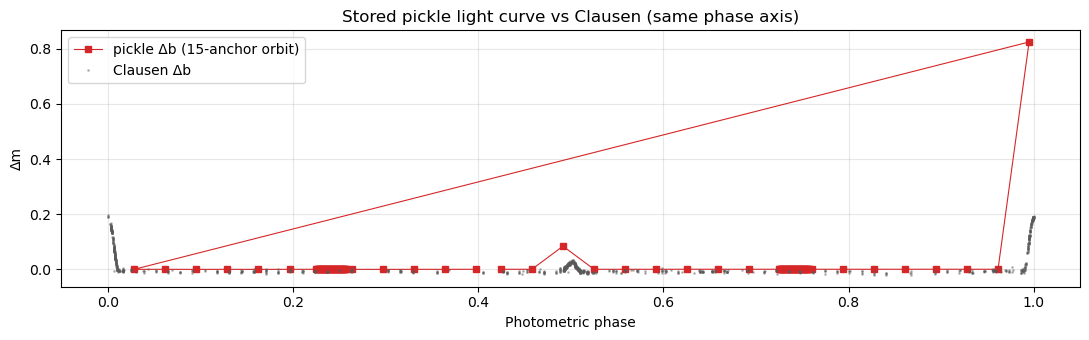

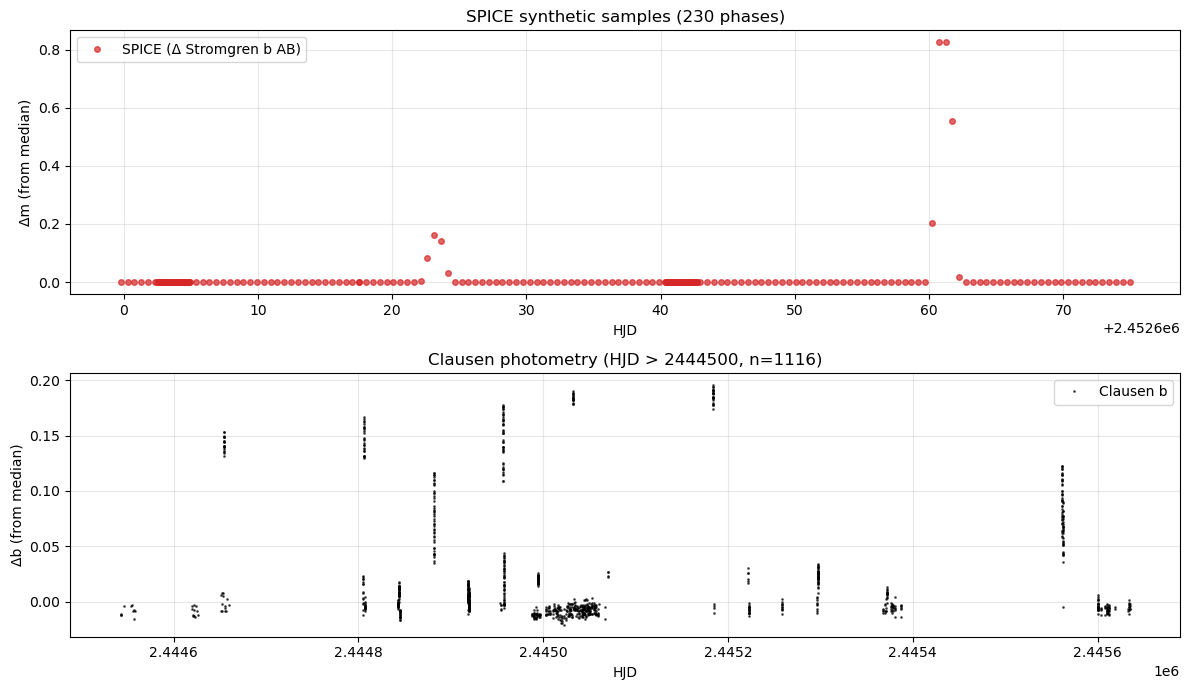

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

ax = axes[0]
ax.plot(HJD_spice, dm_spice, "o", color="tab:red", ms=4, alpha=0.7, label="SPICE (Δ Stromgren b AB)")
ax.set_ylabel("Δm (from median)")
ax.set_xlabel("HJD")
ax.set_title("SPICE synthetic samples (230 phases)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(df_c["HJD_full"], dm_clausen, ".", color="black", ms=2, alpha=0.6, label="Clausen b")
ax.set_ylabel("Δb (from median)")
ax.set_xlabel("HJD")
ax.set_title(f"Clausen photometry (HJD > {4500 + HJD_OFFSET:.0f}, n={len(df_c)})")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Phase-folded comparison (legacy two-panel)

The three-panel figure in **Proper comparison** above is preferred. Below: unshifted vs correlation shift only (can mis-place the deep eclipse at φ = 0).

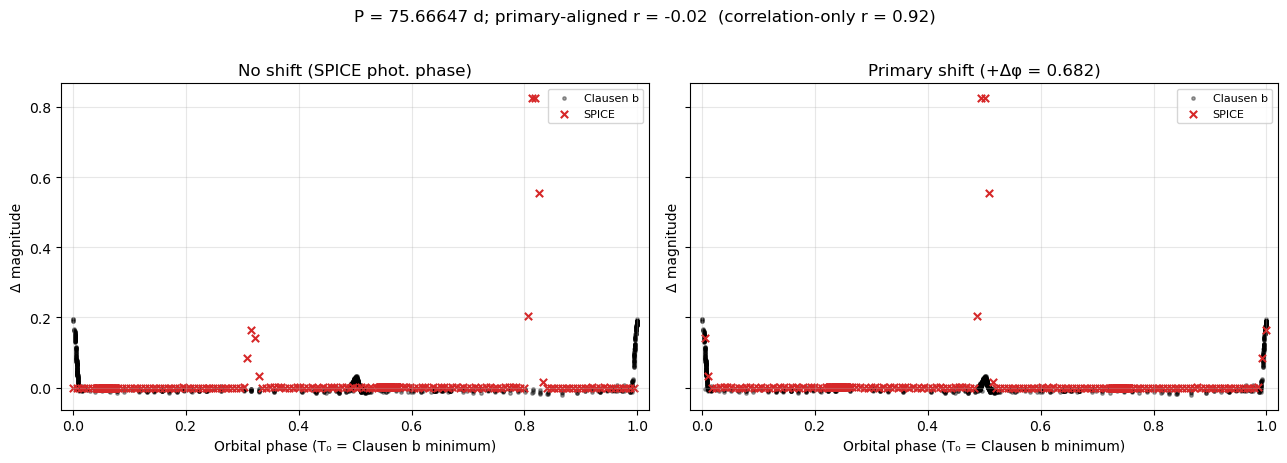

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, ph_s, title in [
    (axes[0], phase_spice_phot, "No shift (SPICE phot. phase)"),
    (axes[1], phase_spice_primary, f"Primary shift (+Δφ = {shift_primary:.3f})"),
]:
    ax.scatter(df_c["phase_phot"], dm_clausen, s=6, c="black", alpha=0.35, label="Clausen b")
    ax.scatter(ph_s, dm_spice, s=28, c="tab:red", marker="x", label="SPICE")
    ax.set_xlabel("Orbital phase (T₀ = Clausen b minimum)")
    ax.set_ylabel("Δ magnitude")
    ax.set_title(title)
    ax.set_xlim(-0.02, 1.02)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(
    f"P = {PERIOD_DAYS} d; primary-aligned r = {r_primary:.2f}  (correlation-only r = {r_spec:.2f})",
    y=1.02,
)
plt.tight_layout()
plt.show()

## Interpolated overlay and residuals (aligned phase)

Smooth Clausen points onto the SPICE phase grid for a direct residual view.

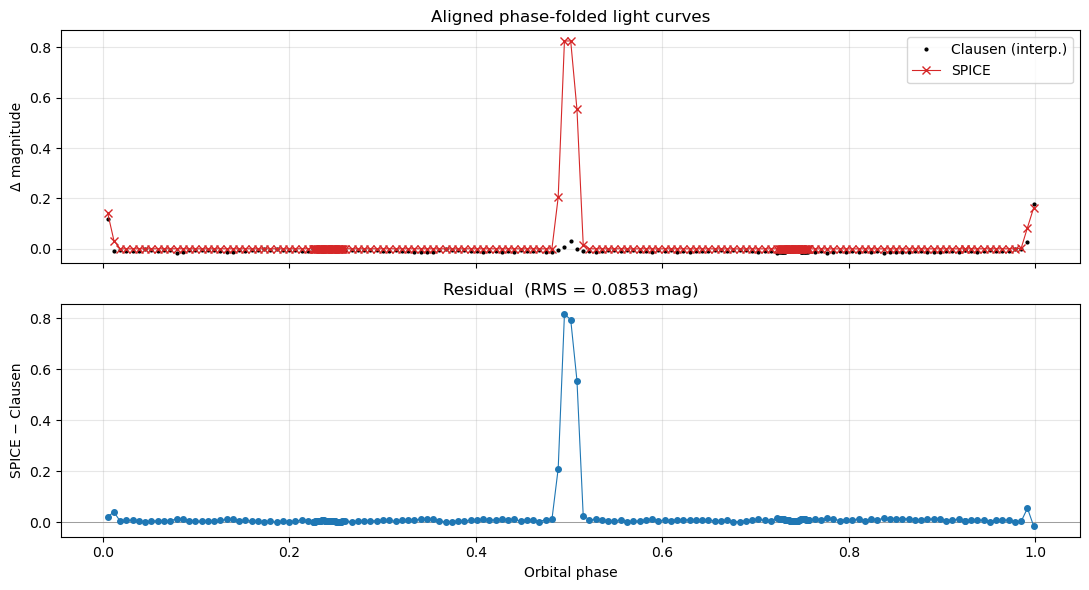

Eclipse windows (SPICE pickle, spectroscopic phase):
  primary: φ ≈ 0.042 – 0.074
  secondary: φ ≈ 0.542 – 0.574


In [12]:
order_s = np.argsort(phase_spice_aligned)
ph_s = phase_spice_aligned[order_s]
dm_s = dm_spice[order_s]

order_c = np.argsort(df_c["phase_phot"])
ph_c = df_c["phase_phot"].to_numpy()[order_c]
dm_c = dm_clausen[order_c]

dm_c_on_spice = np.interp(ph_s, ph_c, dm_c, period=1.0)
residual = dm_s - dm_c_on_spice

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(ph_s, dm_c_on_spice, ".", color="black", ms=4, label="Clausen (interp.)")
axes[0].plot(ph_s, dm_s, "x-", color="tab:red", ms=6, lw=0.8, label="SPICE")
axes[0].set_ylabel("Δ magnitude")
axes[0].set_title("Aligned phase-folded light curves")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color="gray", lw=0.5)
axes[1].plot(ph_s, residual, "o-", color="tab:blue", ms=4, lw=0.8)
axes[1].set_xlabel("Orbital phase")
axes[1].set_ylabel("SPICE − Clausen")
axes[1].set_title(f"Residual  (RMS = {np.sqrt(np.mean(residual**2)):.4f} mag)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Eclipse windows (SPICE pickle, spectroscopic phase):")
for name, win in [("primary", data["primary_eclipse_window_yr"]),
                  ("secondary", data["secondary_eclipse_window_yr"])]:
    ph0 = (win[0] / period_yr + m0 / (2 * np.pi)) % 1.0
    ph1 = (win[1] / period_yr + m0 / (2 * np.pi)) % 1.0
    print(f"  {name}: φ ≈ {ph0:.3f} – {ph1:.3f}")

## Phase-shift scan

Correlation vs additive phase shift (SPICE photometric phase + shift).

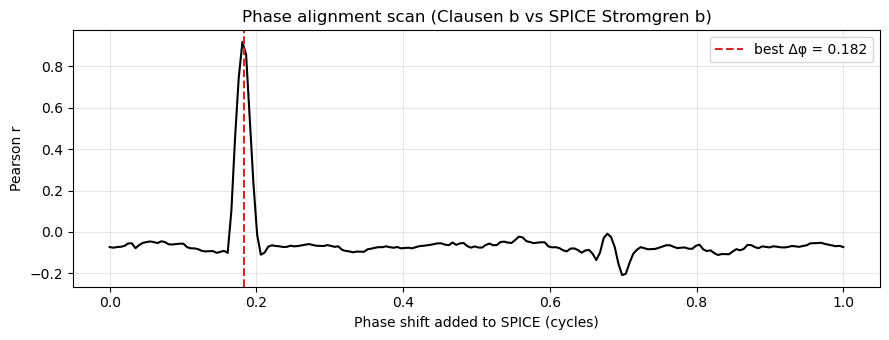

In [13]:
shifts = np.linspace(0, 1, 200)
order_s0 = np.argsort(phase_spice_phot)
ph_s0, dm_s0 = phase_spice_phot[order_s0], dm_spice[order_s0]
ph_c = df_c["phase_phot"].to_numpy()

corrs = []
for sh in shifts:
    ph_shifted = (ph_s0 + sh) % 1.0
    dm_interp = np.interp(ph_c, ph_shifted, dm_s0, period=1.0)
    corrs.append(np.corrcoef(dm_interp, dm_clausen)[0, 1])
corrs = np.array(corrs)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(shifts, corrs, color="black")
ax.axvline(best_shift, color="tab:red", ls="--", label=f"best Δφ = {best_shift:.3f}")
ax.set_xlabel("Phase shift added to SPICE (cycles)")
ax.set_ylabel("Pearson r")
ax.set_title("Phase alignment scan (Clausen b vs SPICE Stromgren b)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()